# Projekt 3 - Klasyfikacja wieloklasowa (LogisticRegression)

## 1. Import bibliotek

In [1]:
import shutil
import warnings
from collections import defaultdict
from pathlib import Path

import cv2 as cv
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.io import imread
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED = 42
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

## 2. Przygotowanie katalogu data_src (10 klas z PlantVillage)

In [2]:
def prepare_simple_data_src(n_classes=10, images_per_class=320):
    base_path = Path(kagglehub.dataset_download("abdallahalidev/plantvillage-dataset"))

    all_dirs = [
        d for d in base_path.rglob("*") if d.is_dir() and not d.name.startswith(".")
    ]
    valid_dirs = [d for d in all_dirs if len(list(d.glob("*.jpg"))) > 100][:n_classes]

    out_path = Path("data_src")
    if out_path.exists():
        shutil.rmtree(out_path)
    out_path.mkdir()

    rng = np.random.default_rng(SEED)

    for class_dir in valid_dirs:
        target_dir = out_path / class_dir.name
        target_dir.mkdir()

        files = [f for f in class_dir.iterdir() if f.is_file()]
        rng.shuffle(files)
        selected = files[:images_per_class]

        for f in selected:
            shutil.copy(f, target_dir / f.name)

    print(f"Przygotowano {len(valid_dirs)} klas w {out_path}")
    return out_path


data_src_path = prepare_simple_data_src()

Przygotowano 10 klas w data_src


## 3. Funkcja gen_train_test i tworzenie katalogu data

In [3]:
def gen_train_test(container_dir, max_category_sample=500):
    src_dir = Path(container_dir)
    out_dir = Path("data")
    train_dir, test_dir = out_dir / "train", out_dir / "test"

    if out_dir.exists():
        shutil.rmtree(out_dir)
    train_dir.mkdir(parents=True)
    test_dir.mkdir(parents=True)

    rng = np.random.default_rng(SEED)
    test_rows = []

    test_per_class = 50

    for class_path in sorted(src_dir.iterdir()):
        if not class_path.is_dir():
            continue

        files = sorted(list(class_path.glob("*")))
        rng.shuffle(files)

        train_files = files[:max_category_sample]
        test_files = files[max_category_sample : max_category_sample + test_per_class]

        cls_train_dir = train_dir / class_path.name
        cls_train_dir.mkdir()
        for f in train_files:
            shutil.copy(f, cls_train_dir / f.name)

        for f in test_files:
            new_name = f"{class_path.name}_{f.name}"
            shutil.copy(f, test_dir / new_name)
            test_rows.append({"filename": new_name, "label": class_path.name})

    pd.DataFrame(test_rows).to_csv(out_dir / "test_labels.csv", index=False)
    print(f"Dane przygotowane w {out_dir}")
    return out_dir


data_path = gen_train_test("data_src", max_category_sample=200)

Dane przygotowane w data


## 4. Funkcje load_train_images i load_test_images

In [4]:
def _preprocess_image(
    image_path,
    newSize=(64, 64),
    interpol=cv.INTER_AREA,
    colorConv=None,
    stand=False,
    ignore_image_a=True,
    norm=True,
):
    img = imread(image_path)

    if ignore_image_a and img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]
    if colorConv is not None:
        img = cv.cvtColor(img, colorConv)

    img = cv.resize(img, newSize, interpolation=interpol).astype(np.float32)

    if norm:
        img /= 255.0
    if stand:
        img = (img - img.mean()) / (img.std() + 1e-8)

    return img.flatten()


def load_train_images(
    container_path,
    newSize=(64, 64),
    interpol=cv.INTER_AREA,
    colorConv=None,
    stand=False,
    ignore_image_a=True,
    norm=True,
    max_sample=200,
):
    path = Path(container_path)
    categories = sorted([d.name for d in path.iterdir() if d.is_dir()])
    train_img, labels = [], []

    for cat in categories:
        files = sorted(list((path / cat).glob("*")))[:max_sample]
        for f in files:
            try:
                train_img.append(
                    _preprocess_image(
                        f, newSize, interpol, colorConv, stand, ignore_image_a, norm
                    )
                )
                labels.append(cat)
            except Exception as e:
                print(f"Błąd {f}: {e}")

    return {
        "data": np.array(train_img),
        "categories_name": categories,
        "categories_count": len(categories),
        "labels": labels,
    }


def load_test_images(
    container_path,
    newSize=(64, 64),
    interpol=cv.INTER_AREA,
    colorConv=None,
    stand=False,
    ignore_image_a=True,
    norm=True,
    max_sample=200,
):
    path = Path(container_path)
    df = pd.read_csv(path.parent / "test_labels.csv")

    if "filename" not in df.columns or "label" not in df.columns:
        raise ValueError(
            "Plik test_labels.csv musi zawierac kolumny: filename oraz label"
        )

    sampled_parts = []
    for label, group in df.groupby("label"):
        sampled_group = group.sample(
            n=min(len(group), max_sample),
            random_state=SEED,
        ).copy()
        sampled_group["label"] = label
        sampled_parts.append(sampled_group)

    if sampled_parts:
        df = pd.concat(sampled_parts, ignore_index=True)
    else:
        return {
            "data": np.array([]),
            "categories_name": [],
            "categories_count": 0,
            "labels": [],
        }

    test_img, labels = [], []

    for _, row in df.iterrows():
        try:
            test_img.append(
                _preprocess_image(
                    path / row["filename"],
                    newSize,
                    interpol,
                    colorConv,
                    stand,
                    ignore_image_a,
                    norm,
                )
            )
            labels.append(row["label"])
        except Exception as e:
            print(f"Błąd {row['filename']}: {e}")

    return {
        "data": np.array(test_img),
        "categories_name": sorted(df["label"].unique()),
        "categories_count": df["label"].nunique(),
        "labels": labels,
    }

## 5. Wczytanie danych treningowych i testowych

In [5]:
TARGET_SIZE = (128, 128)
TRAIN_PER_CLASS = 200
TEST_PER_CLASS = 60

train_set = load_train_images(
    container_path="data/train",
    newSize=TARGET_SIZE,
    colorConv=cv.COLOR_RGB2GRAY,
    max_sample=TRAIN_PER_CLASS,
)

test_set = load_test_images(
    container_path="data/test",
    newSize=TARGET_SIZE,
    colorConv=cv.COLOR_RGB2GRAY,
    max_sample=TEST_PER_CLASS,
)

print(f"Dane treningowe: {train_set['data'].shape}")
print(f"Dane testowe:   {test_set['data'].shape}")

Dane treningowe: (2000, 16384)
Dane testowe:   (500, 16384)


## 6. Kodowanie etykiet

In [6]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_set["labels"])
y_test = label_encoder.transform(test_set["labels"])

X_train, X_test = train_set["data"], test_set["data"]

print("Mapowanie klas (pierwsze 10):")
for i, name in enumerate(label_encoder.classes_[:10]):
    print(f"{i} -> {name}")

Mapowanie klas (pierwsze 10):
0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust
3 -> Apple___healthy
4 -> Blueberry___healthy
5 -> Cherry_(including_sour)___Powdery_mildew
6 -> Cherry_(including_sour)___healthy
7 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 -> Corn_(maize)___Common_rust_
9 -> Corn_(maize)___healthy


## 7. Trening i test: ovr vs multinomial

In [7]:
from sklearn.multiclass import OneVsRestClassifier

results = []
conf_mats = {}

print("Trenowanie ovr")
ovr_model = OneVsRestClassifier(
    LogisticRegression(solver="liblinear", max_iter=500, random_state=SEED), n_jobs=-1
)
ovr_model.fit(X_train, y_train)
y_pred_ovr = ovr_model.predict(X_test)

print("Trenowanie multinomial")
multi_model = LogisticRegression(
    solver="saga", max_iter=500, random_state=SEED, n_jobs=-1
)
multi_model.fit(X_train, y_train)
y_pred_multi = multi_model.predict(X_test)

preds = {"ovr": y_pred_ovr, "multinomial": y_pred_multi}

for name, y_pred in preds.items():
    conf_mats[name] = confusion_matrix(y_test, y_pred)
    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        }
    )

metrics_df = pd.DataFrame(results).set_index("model")
display(metrics_df)

Trenowanie ovr
Trenowanie multinomial


c:\Users\Michal\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,accuracy,precision,recall,f1
model,,,,
ovr,0.478,0.505718,0.478,0.482261
multinomial,0.548,0.561848,0.548,0.551038


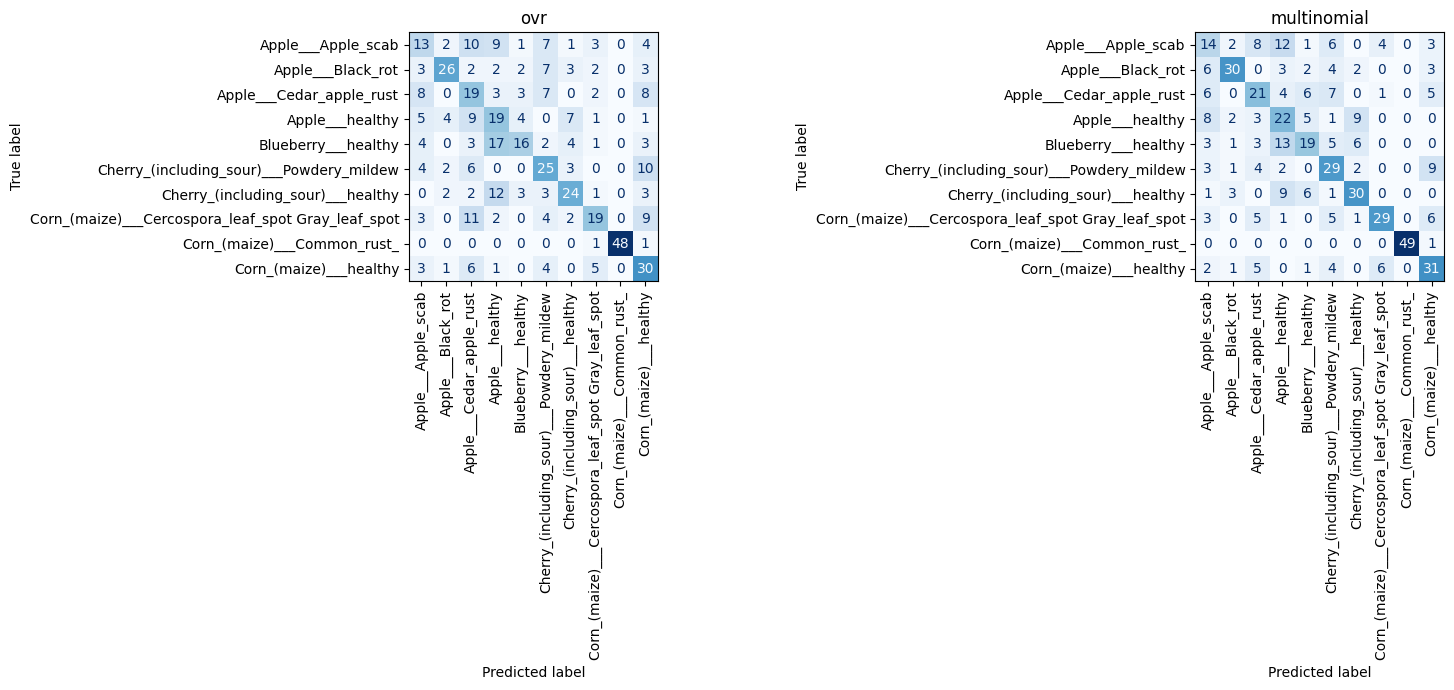

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, name in enumerate(["ovr", "multinomial"]):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=conf_mats[name], display_labels=label_encoder.classes_
    )
    disp.plot(ax=axes[i], cmap="Blues", xticks_rotation=90, colorbar=False)
    axes[i].set_title(f"{name}")

plt.tight_layout()
plt.show()